In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from mystatsfunctions import OLSE,LMoments
import sys
import pathlib
from fair import *
from fair import return_empty_emissions, run_FaIR
import argparse

from time import perf_counter

In [2]:
def interpolate_to_model_grid(ds, sh=False):

    # load reference grid and pressure at model levels
    model_level_p = pd.read_csv('/home/e/ermis/Irene-damages/model_to_pressure_levels.csv')['ph [hPa]'].values[::-1][:137] # half levels pressure 
    if sh: 
        ref_ds = xr.open_dataset('/gf5/predict/AWH019_ERMIS_ATMICP/test_ATMICP/TEMPBLOB_IC/temperature_blob_model_grid.grb2')
    else:
        ref_ds = xr.open_dataset('/home/e/ermis/test_ATMICP/grid_q.nc', engine='netcdf4')
    
    # horizontal interpolation
    tmp = ds.interp(latitude=ref_ds.latitude, longitude=ref_ds.longitude, method='linear')

    # vertical interpolation
    tmp = tmp.interp(level=model_level_p, method='linear', kwargs={'fill_value': 'extrapolate'})

    # add output into frame of reference dataset
    target = xr.zeros_like(ref_ds) + tmp.values[::-1]

    return target.fillna(0)

def get_HC5():

    ## HadCRUT5
    HC5 = xr.open_dataset('{}source/ancil/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.nc'.format(AOPP_BASE_PATH))
    HC5 = HC5.tas_mean.to_pandas()
    HC5.index = HC5.index.year

    return HC5

def get_erf(end_year=2022):

    ## ERF components from AR6
    erf_ar6 = pd.read_csv('{}source/ancil/AR6_ERF_1750-2019.csv'.format(AOPP_BASE_PATH),index_col=0)
    erf_ar6.loc[:,'ghg'] = erf_ar6.loc[:,'total_anthropogenic'] - erf_ar6.loc[:,'aerosol']
    
    ### extend ERF to 2022
    ssp245_erf = pd.read_csv('{}source/ancil/ERF_ssp245_1750-2500.csv'.format(AOPP_BASE_PATH),index_col=0)
    ssp245_erf['aerosol'] = ssp245_erf.loc[:,'aerosol-radiation_interactions'] + ssp245_erf.loc[:,'aerosol-cloud_interactions']
    ssp245_erf.loc[:,'ghg'] = ssp245_erf.loc[:,'total_anthropogenic'] - ssp245_erf.loc[:,'aerosol']
    
    # for year in range(2020,end_year+1): 
    for year in [2020, 2021, 2022]: # not using end_year here, why?
        erf_ar6.loc[year] = ssp245_erf.loc[year] * erf_ar6.loc[year-1] / ssp245_erf.loc[year-1]

    return erf_ar6

def get_AWI(end_year=2022):

    HC5 = get_HC5()
    erf = get_erf(end_year=end_year)

    ## ant / nat FaIR run
    fair_erf = pd.DataFrame(index=erf.index,columns=pd.MultiIndex.from_product([['ant','aer','nat'],['forcing']]),
                            data=pd.concat([erf.loc[:,'ghg'],erf.loc[:,'aerosol'],
                                            erf.loc[:,'total_natural']], axis=1).values)
    fair_emms = return_empty_emissions(start_year=1750,end_year=end_year,scen_names=['ant','aer','nat'])
    fair_temps = run_FaIR(emissions_in=fair_emms,forcing_in=fair_erf)['T'].loc[1850:]

    ## regress HadCRUT5 onto FaIR temperature output & define anthropogenic warming index
    X = np.column_stack([np.ones(fair_temps.loc[:end_year].index.size),fair_temps.loc[:end_year]])
    Y = HC5.loc[1850:end_year].values[:,None]
    mlr = OLSE.multiple(Y)
    mlr.fit(X)
    AWI = ( mlr.B[1]*fair_temps.aer + mlr.B[2]*fair_temps.ant ).default

    return AWI

In [3]:
# definitions
AOPP_BASE_PATH = '/gf5/predict/AWH019_ERMIS_ATMICP/DATA/'
DELTA_PATH = f'{AOPP_BASE_PATH}/postproc/deltas/'

PERTURB_MONTH = [8] # month to create delta for
VAR = 'q' # variable to create delta for

START_YEAR = 1979
END_YEAR = 2021

assert(END_YEAR <= 2022, "End year cannot be greater than 2023, as this is the latest year for which HC5 is downloaded.")

<>:11: SyntaxWarning: assertion is always true, perhaps remove parentheses?
<>:11: SyntaxWarning: assertion is always true, perhaps remove parentheses?
/tmp/user/27529/ipykernel_3494503/2757370215.py:11: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(END_YEAR <= 2022, "End year cannot be greater than 2023, as this is the latest year for which HC5 is downloaded.")


In [ ]:
print("### Importing data ###")

# Load ERA5 data
era5_var  = xr.open_dataset(f'{AOPP_BASE_PATH}/ERA5/{VAR}_monthly/{VAR}_mon_ERA5_0.25x0.25_197901-202512.nc').rename(
    {'valid_time': 'time', 'pressure_level': 'level'}
)
sh_var = {'q': False, 't': True, 'd': True,
            'vo': True, 'u': False, 'v': False}[VAR] # is this variable on the spherical harmonic grid?

# Anthropogenic warming index
awi = get_AWI(end_year=2022) # has to match available HADCRUT5 data

# Select only the specified month
months = era5_var['time'].dt.month

era5_var = era5_var.chunk({"time": -1}) # massive speedup!

for month in PERTURB_MONTH:
    
    # TODO check year
    var_years = era5_var.sel(time=months.isin([month])).groupby('time.year').mean(dim='time').sel(year=slice(START_YEAR, END_YEAR)) # select the specified month and average each year

    print(f"### Regressing using data from {START_YEAR} to {END_YEAR} ###")
    
    # Interpolate variable
    timeslices = [x for x in np.arange(START_YEAR,END_YEAR+1,1)] 
    X = np.array([awi.loc[timeslice] for timeslice in timeslices])
    X = X[:,None,None,None]             # AWI
    Y = var_years[VAR].squeeze().values # ERA5 variable
    # olsreg = OLSE.simple( Y = Y )       # Need to be same number of years

    # create objects for computation
    # olsreg.X = np.ma.array(X, mask=olsreg._mask)

    # w = olsreg.W

    # x = olsreg.X
    # y = olsreg.Y
    # olsreg.fit( X = X )

    # compute estimated attributable warming over 1850-1900 to endyear period
    # var3d_out = olsreg.b1 * (awi.loc[END_YEAR] - awi.loc[1850:1900].mean())

### Importing data ###
Integrating 3 scenarios, 1 gas cycle parameter sets, 1 thermal response parameter sets, over ['bc', 'bc|aci', 'bc|bc_on_snow', 'c2f6', 'c3f8', 'c4f10', 'c5f12', 'c6f14', 'c7f16', 'c8f18', 'c_c4f8', 'carbon_dioxide', 'carbon_tetrachloride', 'carbon_tetrachloride|o3', 'cf4', 'cfc11', 'cfc113', 'cfc113|o3', 'cfc114', 'cfc114|o3', 'cfc115', 'cfc115|o3', 'cfc11|o3', 'cfc12', 'cfc12|o3', 'ch2cl2', 'ch2cl2|o3', 'ch3ccl3', 'ch3ccl3|o3', 'chcl3', 'chcl3|o3', 'co', 'co|o3', 'halon1202', 'halon1202|o3', 'halon1211', 'halon1211|o3', 'halon1301', 'halon1301|o3', 'halon2402', 'halon2402|o3', 'hcfc141b', 'hcfc141b|o3', 'hcfc142b', 'hcfc142b|o3', 'hcfc22', 'hcfc22|o3', 'hfc125', 'hfc134a', 'hfc143a', 'hfc152a', 'hfc227ea', 'hfc23', 'hfc236fa', 'hfc245fa', 'hfc32', 'hfc365mfc', 'hfc4310mee', 'methane', 'methane|strat_h2o', 'methane|o3', 'methyl_bromide', 'methyl_bromide|o3', 'methyl_chloride', 'methyl_chloride|o3', 'nf3', 'nh3', 'nitrous_oxide', 'nitrous_oxide|o3', 'nmvoc', 'nmvo

/home/e/ermis/FAIR-2.0.0-alpha/fair/fair_runner.py:127: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0).apply(pd.to_numeric)
100%|██████████| 272/272 [00:00<00:00, 3774.74 timestep/s]
/home/e/ermis/nobackups/miniforge3/envs/debug_forecast-icp/lib/python3.11/site-packages/xarray/core/indexing.py:1624: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


### Regressing using data from 1979 to 2021 ###


In [13]:
qtest = xr.open_dataset(f'{DELTA_PATH}/q_8_delta_ERA5_1979-2021.grb2')

In [14]:
qtest

<xarray.Dataset> Size: 569MB
Dimensions:     (hybrid: 137, latitude: 721, longitude: 1440)
Coordinates:
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
  * hybrid      (hybrid) float64 1kB 1.0 2.0 3.0 4.0 ... 134.0 135.0 136.0 137.0
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    valid_time  datetime64[ns] 8B ...
Data variables:
    q           (hybrid, latitude, longitude) float32 569MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-15T14:42 GRIB to CDM+CF via cfgrib-0.9.1...

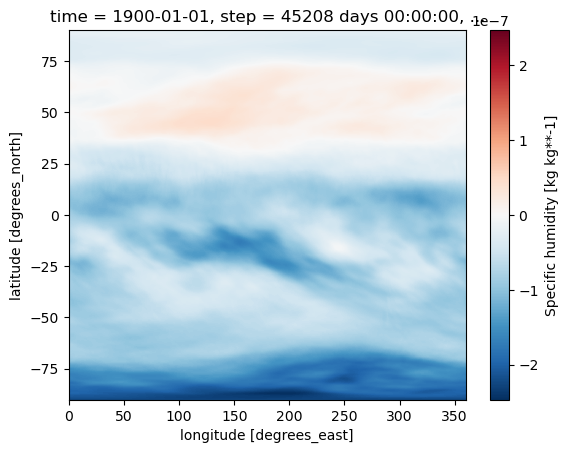

In [21]:
qtest.q.sel(hybrid=10).plot()